# 911 Emergency Dispatch Data Analysis

In this notebook, we will analyze the 911 emergency dispatch dataset of Baguio City Philippines to uncover trends regarding incident types, responder workloads, peak emergency hours, and high-frequency locations.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/911.csv')

print(df)

      case_no           date      time responder  \
0         1.0     1 Jan 2023  12:25 AM       BFP   
1         2.0     1 Jan 2023  12:43 PM    CDRRMO   
2         3.0     1 Jan 2023   2:49 PM    CDRRMO   
3         4.0     1 Jan 2023   7:52 PM       EMS   
4         5.0     2 Jan 2023   3:23 AM    CDRRMO   
...       ...            ...       ...       ...   
3127   3870.0  6 February 24   6:30 PM       911   
3128   3871.0  6 February 24   5:27 PM    CDRRMO   
3129   3872.0  6 February 24   7:44 PM    CDRRMO   
3130   3873.0  6 February 24   3:02 AM       911   
3131   3874.0  6 February 24   6:47 AM       911   

                                          incident_type  \
0                                           Forest Fire   
1                                               Suicide   
2     Ambulance assistance  (former hospital transport)   
3     Ambulance assistance  (former hospital transport)   
4     Ambulance assistance  (former hospital transport)   
...                  

## 1. Categorical Analysis: What is happening?
First, let's look at the types of incidents that are most frequently reported. We will count the occurrences of each `incident_type` and plot the top 10 as a horizontal bar chart.

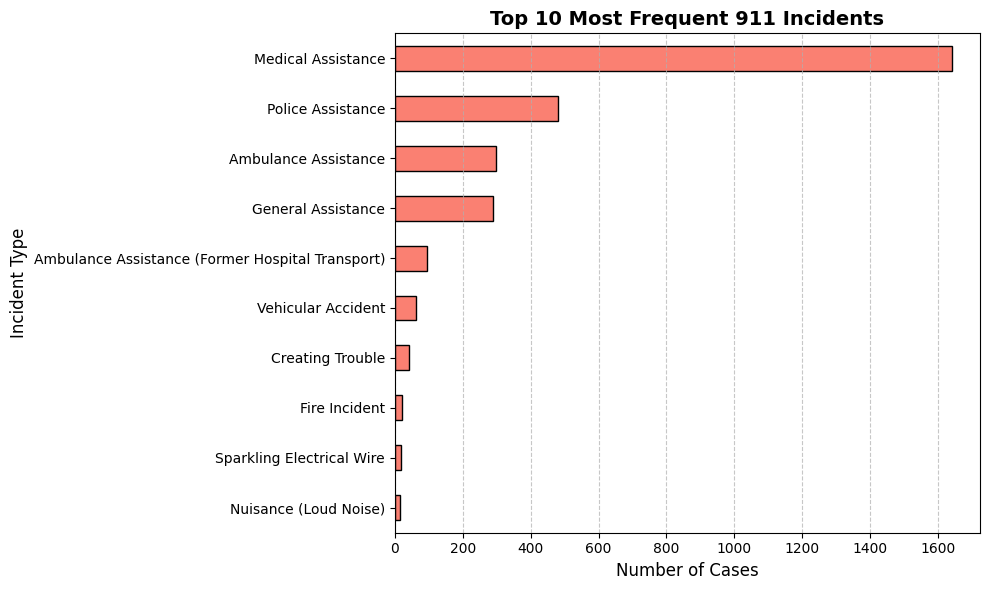

In [17]:
# 1. CLEAN THE DATA FIRST
# Remove asterisks, strip invisible spaces, and force Title Case (e.g., "police assistance" -> "Police Assistance")
df['incident_type'] = df['incident_type'].str.replace('*', '', regex=False).str.strip().str.title()

# Optional: If there are accidental double spaces in the middle of words (e.g., "Forest  Fire")
df['incident_type'] = df['incident_type'].str.replace(r'\s+', ' ', regex=True)

# 2. GET THE TOP 10 FREQUENT INCIDENTS
top_incidents = df['incident_type'].value_counts().head(10)

# 3. CREATE THE CHART
plt.figure(figsize=(10, 6))
top_incidents.sort_values().plot(kind='barh', color='salmon', edgecolor='black')

# Formatting the plot
plt.title('Top 10 Most Frequent 911 Incidents', fontsize=14, fontweight='bold')
plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('Incident Type', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

### Insight: Incident Categories
Based on the frequency distribution, **Medical Assistance** makes up the vast majority of dispatch calls, significantly outpacing high-severity events like residential or forest fires. There is also a consistent baseline of **Police Assistance** requests.
* **Actionable Takeaway:** Resource planning and budgeting should heavily prioritize emergency medical services (EMS) and transport vehicles, as they are the most strained assets in the daily dispatch cycle.

## 2. Resource Allocation: Who is responding?
Next, we want to see the workload distribution among the different responding agencies (e.g., 911, CDRRMO, BFP, Police Stations). We will use a standard bar chart to visualize who handles the most cases.

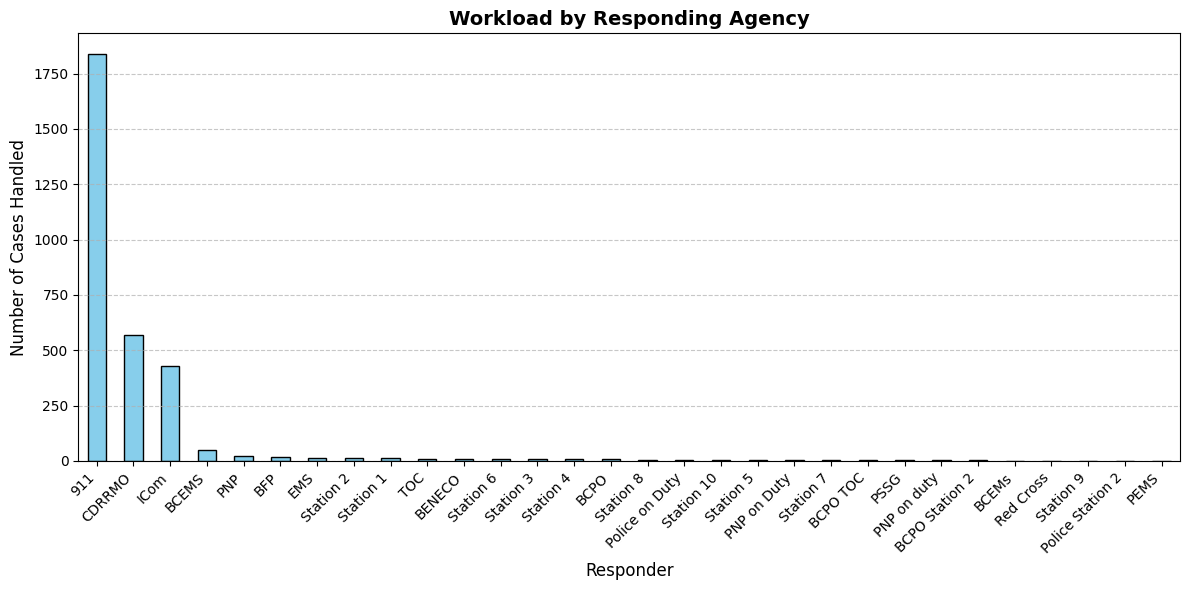

In [7]:
# Count the number of cases per responder
responder_counts = df['responder'].value_counts().head(30)

# Create a vertical bar chart
plt.figure(figsize=(12, 6))
responder_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Formatting the plot
plt.title('Workload by Responding Agency', fontsize=14, fontweight='bold')
plt.xlabel('Responder', fontsize=12)
plt.ylabel('Number of Cases Handled', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

### Insight: Responder Workload
The chart highlights that **911** carries the heaviest case volume by a significant margin. This suggests that the central 911 dispatch acts as the primary intake and triage point, and likely resolves a massive portion of calls directly without needing to dispatch specialized units like the BFP or specific police stations.
* **Actionable Takeaway:** Because the central 911 hub absorbs the bulk of the initial shock, funding should prioritize the call center's infrastructure—such as upgrading triage software or hiring more primary operators—to prevent bottlenecks before cases are routed to other agencies.

## 3. Temporal Analysis: When do emergencies happen?
To find the "peak hours" for emergencies, we need to extract the hour from our `time` column. We will temporarily convert the `time` string into a datetime object just to grab the hour (0 to 23) and then plot the call volume throughout the day.

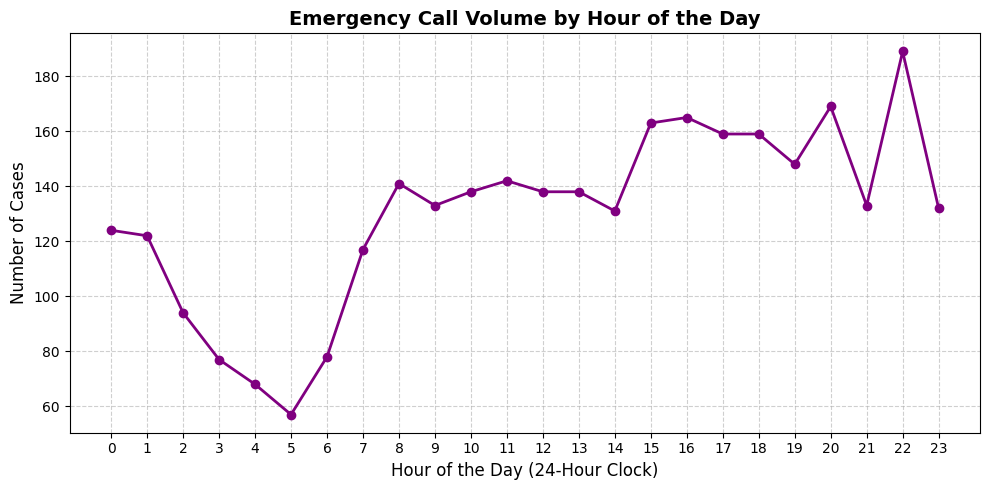

In [8]:
# Convert the 'time' column to a datetime format to easily extract the hour
temp_time = pd.to_datetime(df['time'], format='mixed', errors='coerce')
df['hour'] = temp_time.dt.hour

# Count incidents per hour and sort by the hour of the day (0 to 23)
hourly_counts = df['hour'].value_counts().sort_index()

# Create a line chart with markers
plt.figure(figsize=(10, 5))
plt.plot(hourly_counts.index, hourly_counts.values, marker='o', color='purple', linewidth=2)

# Formatting the plot
plt.title('Emergency Call Volume by Hour of the Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the Day (24-Hour Clock)', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.xticks(range(0, 24)) # Show all 24 hours on the x-axis
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()

### Insight: Temporal Trends (Peak Hours)
The call volume follows a distinct and highly active 24-hour cycle. The quietest period is early morning, bottoming out at 5:00 AM. Volume rises steadily as the workday begins and plateaus between 8:00 AM and 2:00 PM. However, the most critical finding is the massive volatility and extreme spikes in the evening. The highest peak of the entire day occurs at **10:00 PM (Hour 22)**, with secondary high-volume periods occurring through the late afternoon and early evening (3:00 PM - 6:00 PM).
* **Actionable Takeaway:** Shift schedules must be adjusted to handle the late-night rush. Operating on a standard 9-to-5 schedule will leave emergency services severely understaffed during the 8:00 PM to midnight window. Staggering shifts to ensure maximum responder and dispatcher overlap at 10:00 PM is critical, while the 3:00 AM to 6:00 AM window can safely operate on a lighter "skeleton crew."

## 4. Location Hotspots: Where are emergencies happening?
Finally, let's identify the busiest locations. Because addresses can be highly specific (like a house number), we will just plot the top 20 exact text matches in the `location` column to see which general areas or landmarks pop up the most.

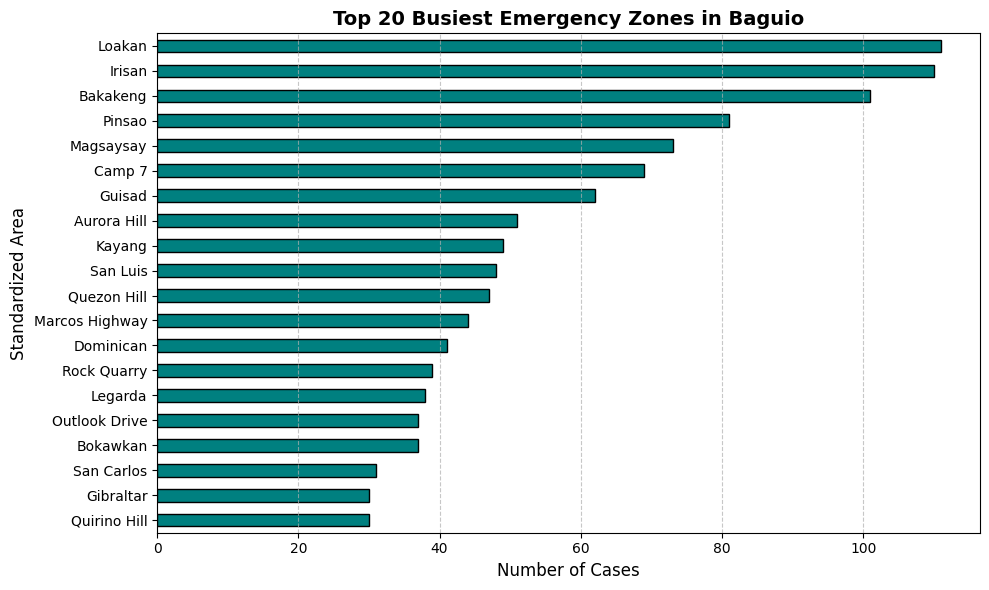

In [16]:
# 1. A tailor-made list of keywords based on the actual CSV
keywords = [
    'Hospital/Medical Transfer', # A special bucket we'll create below
    'Irisan', 'Camp 7', 'Bakakeng', 'Pinsao', 'Loakan', 'San Luis',
    'Guisad', 'Aurora Hill', 'Quezon Hill', 'San Carlos', 'Outlook Drive',
    'Rock Quarry', 'Legarda', 'Session Road', 'Burnham', 'Magsaysay',
    'Marcos Highway', 'Dominican', 'Camp Allen', 'Kayang', 'Gibraltar',
    'Balacbac', 'Botanical', 'Asin', 'Fairview', 'Trinidad',
    'Malcolm Square', 'San Vicente', 'Naguilian', 'Honeymoon', 'Dontogan',
    'Bokawkan', 'Quirino Hill', 'Melvin Jones', 'Lopez Jaena', 'Pinget',
    'Brookside', 'City Camp', 'Cabinet Hill', 'Crystal Cave', 'Sanitary Camp',
    'Kisad', 'Leonard Wood', 'Leonila Hill', 'Mines View'
]

def find_keyword(address):
    # Handle empty/null values
    if pd.isna(address):
        return 'Unknown'

    address_upper = str(address).upper()

    # Check for medical transfers/locations first (very common in your data)
    if any(med in address_upper for med in ['BGH', 'BGHMC', 'HOSPITAL', 'NDCH', 'SLU']):
        return 'Hospital/Medical Area'

    # Check against our custom Baguio keyword list
    for kw in keywords:
        if kw.upper() in address_upper:
            return kw

    return 'Other / Unlisted' # If no keywords match

# 2. Apply this function to create a new, clean column
df['clean_location'] = df['location'].apply(find_keyword)

# 3. Filter out 'Other / Unlisted' and the 'Hospital' group to focus on actual residential/commercial hotspots
filtered_df = df[~df['clean_location'].isin(['Other / Unlisted', 'Hospital/Medical Area'])]

# 4. Get the Top 20 Busiest True Locations
top_locations = filtered_df['clean_location'].value_counts().head(20)

# 5. Create the chart
plt.figure(figsize=(10, 6))
top_locations.sort_values().plot(kind='barh', color='teal', edgecolor='black')

# Formatting the plot
plt.title('Top 20 Busiest Emergency Zones in Baguio', fontsize=14, fontweight='bold')
plt.xlabel('Number of Cases', fontsize=12)
plt.ylabel('Standardized Area', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

### Insight: Geographic Hotspots (Standardized Zones)
By cleaning and standardizing the raw address data, the chart clearly reveals that the highest volume of local emergencies is concentrated in massive residential and transit corridors—specifically **Bakakeng**, **Loakan**, **Pinsao**, and **Irisan**. These areas either have incredibly high population densities, major student populations, or serve as primary arterial highways in and out of the city.
* **Actionable Takeaway:** Centralized dispatch from the Baguio city center is likely causing delayed response times due to heavy traffic when reaching these outer rims. Emergency services should evaluate staging "forward-deployed" units or establishing permanent satellite responder hubs in the southern (Bakakeng/Loakan) and northwestern (Irisan/Pinsao) sectors to drastically cut down travel time during critical incidents.